In [ ]:
!nvidia-smi

Sat Feb 22 02:51:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
!pip install ultralytics

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 35.5/112.6 GB disk)


In [ ]:
from ultralytics import YOLO
from IPython.display import Image

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nFnQ15RsHBDhcLJrA0F8")
project = rf.workspace("university-of-southeastern-philippines-cnl9c").project("philippine-license-plates")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
dataset.location

'/content/Philippine-license-plates-2'

In [ ]:
!yolo task=detect mode=train data={dataset.location}/data.yaml model="yolo11n.pt" epochs=50 imgsz=640

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Philippine-license-plates-2/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_

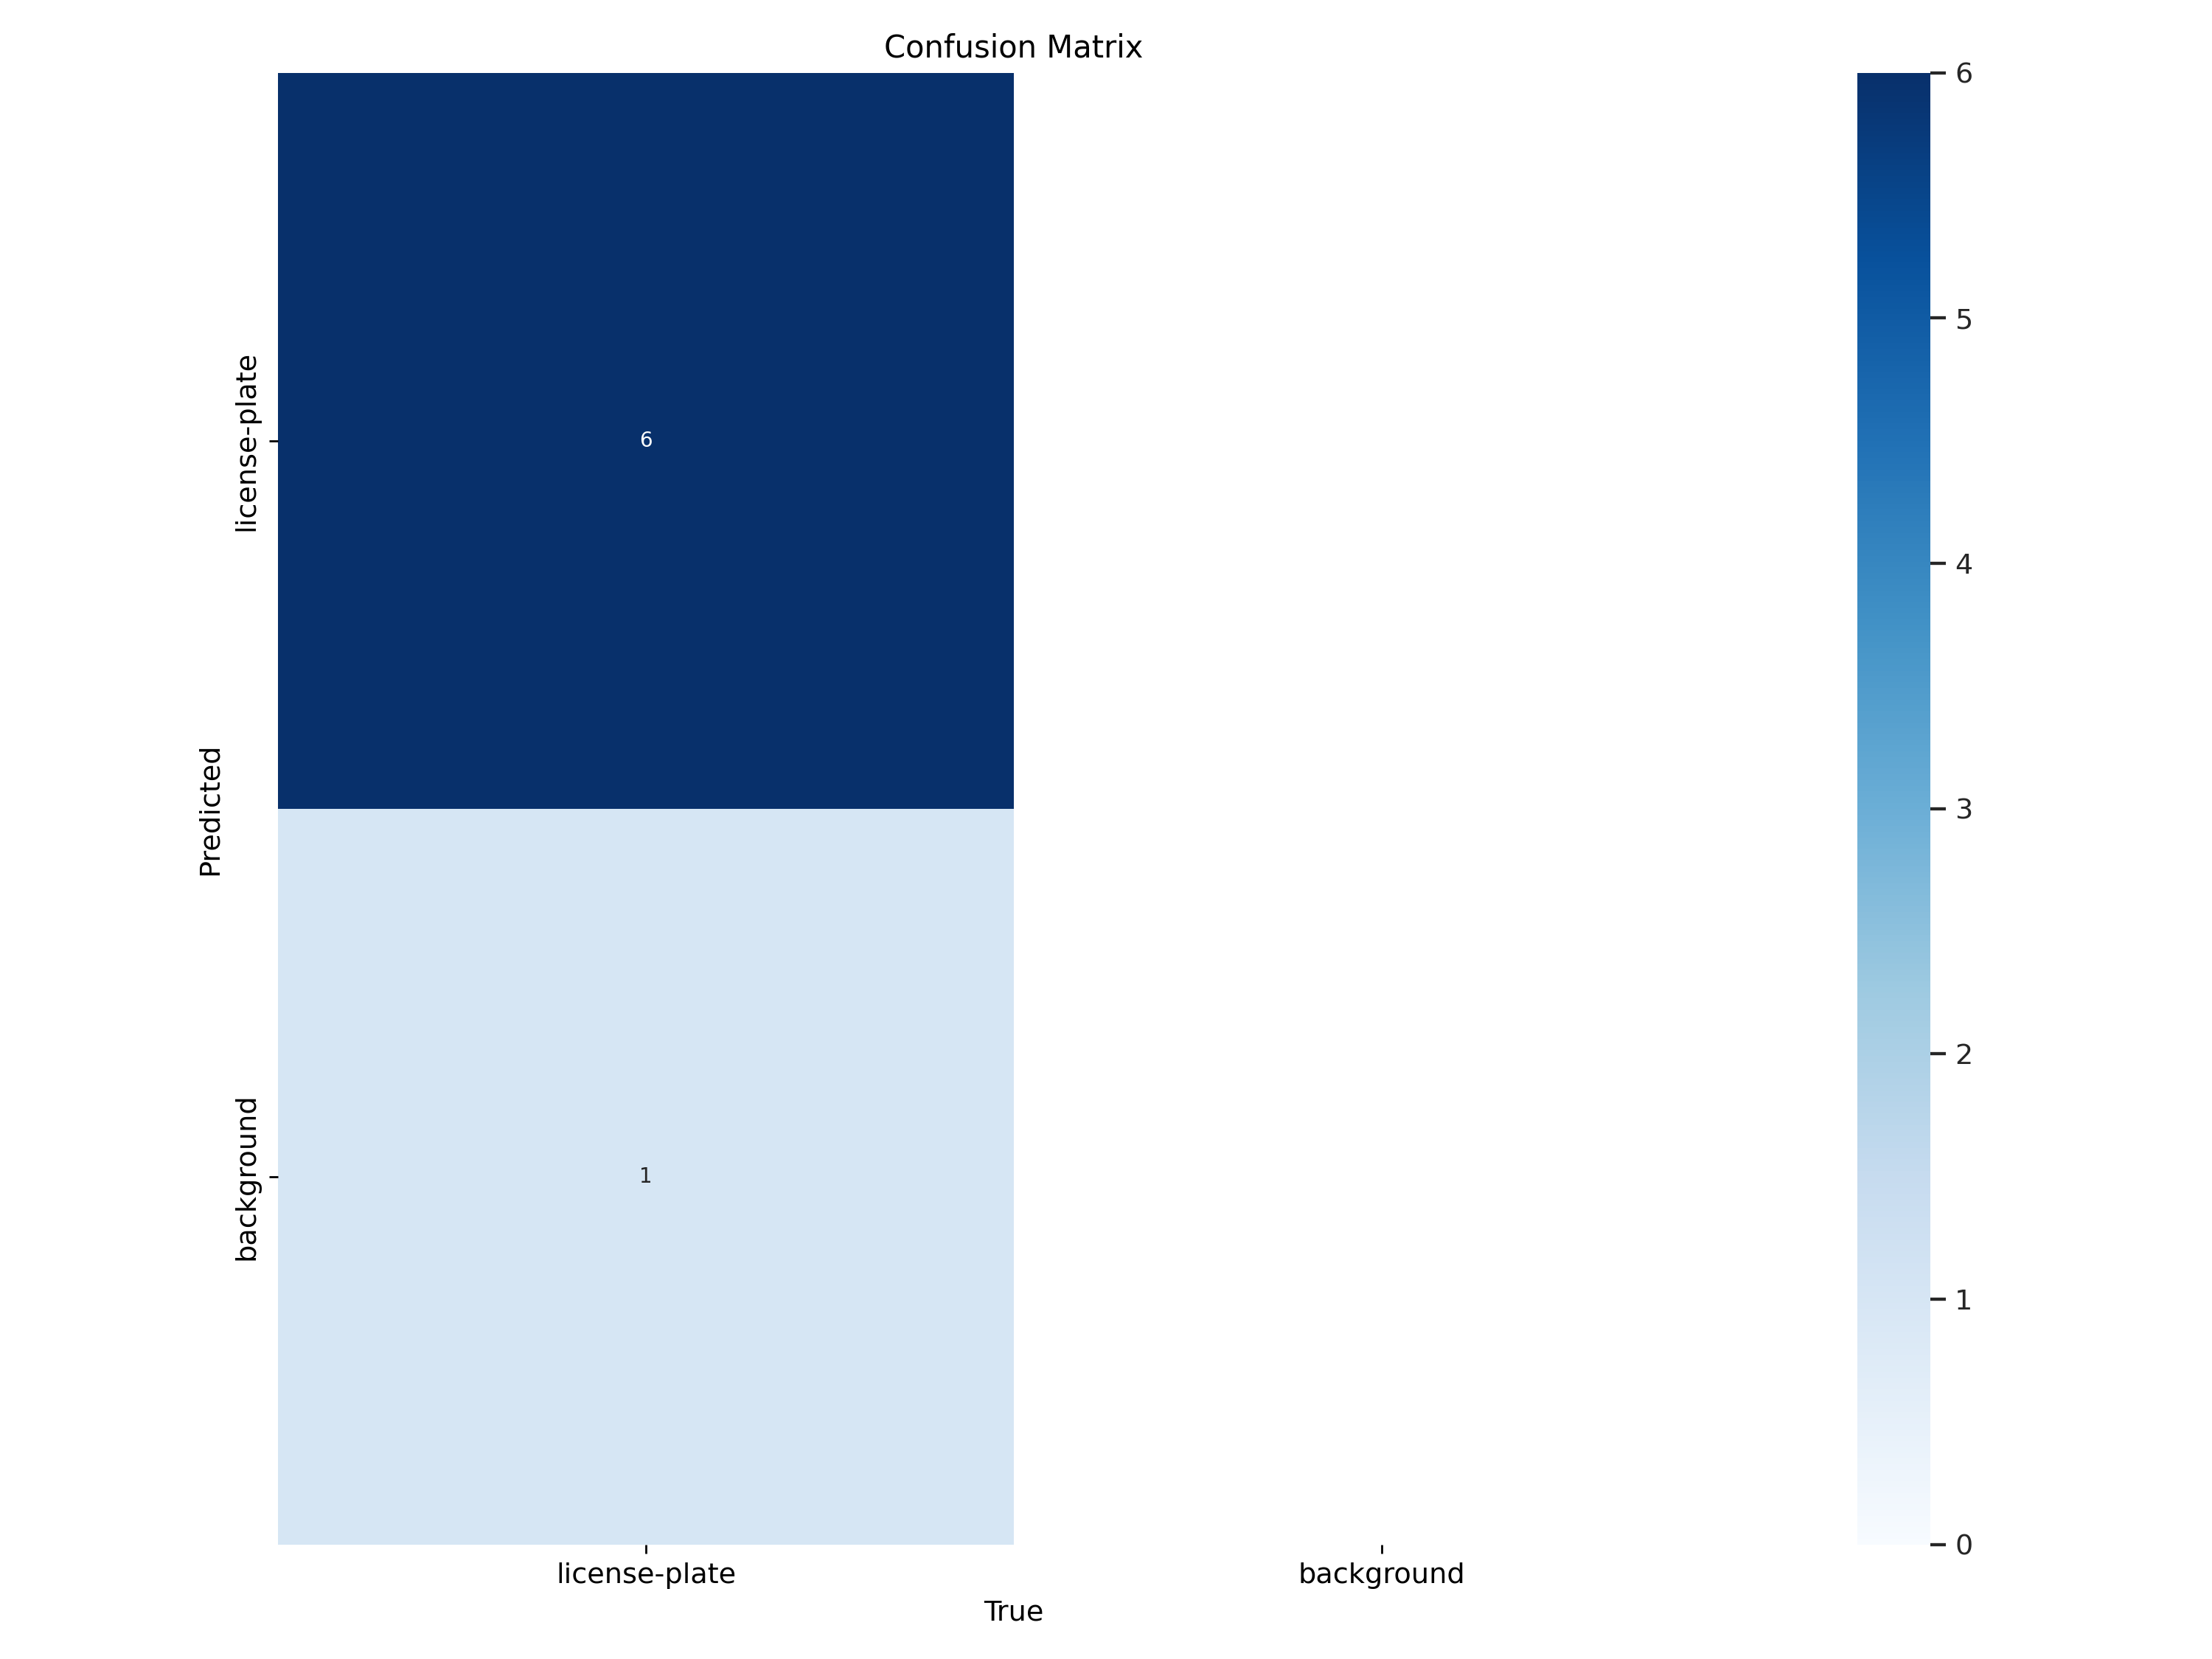

In [ ]:
Image("/content/runs/detect/train2/confusion_matrix.png", width=600)

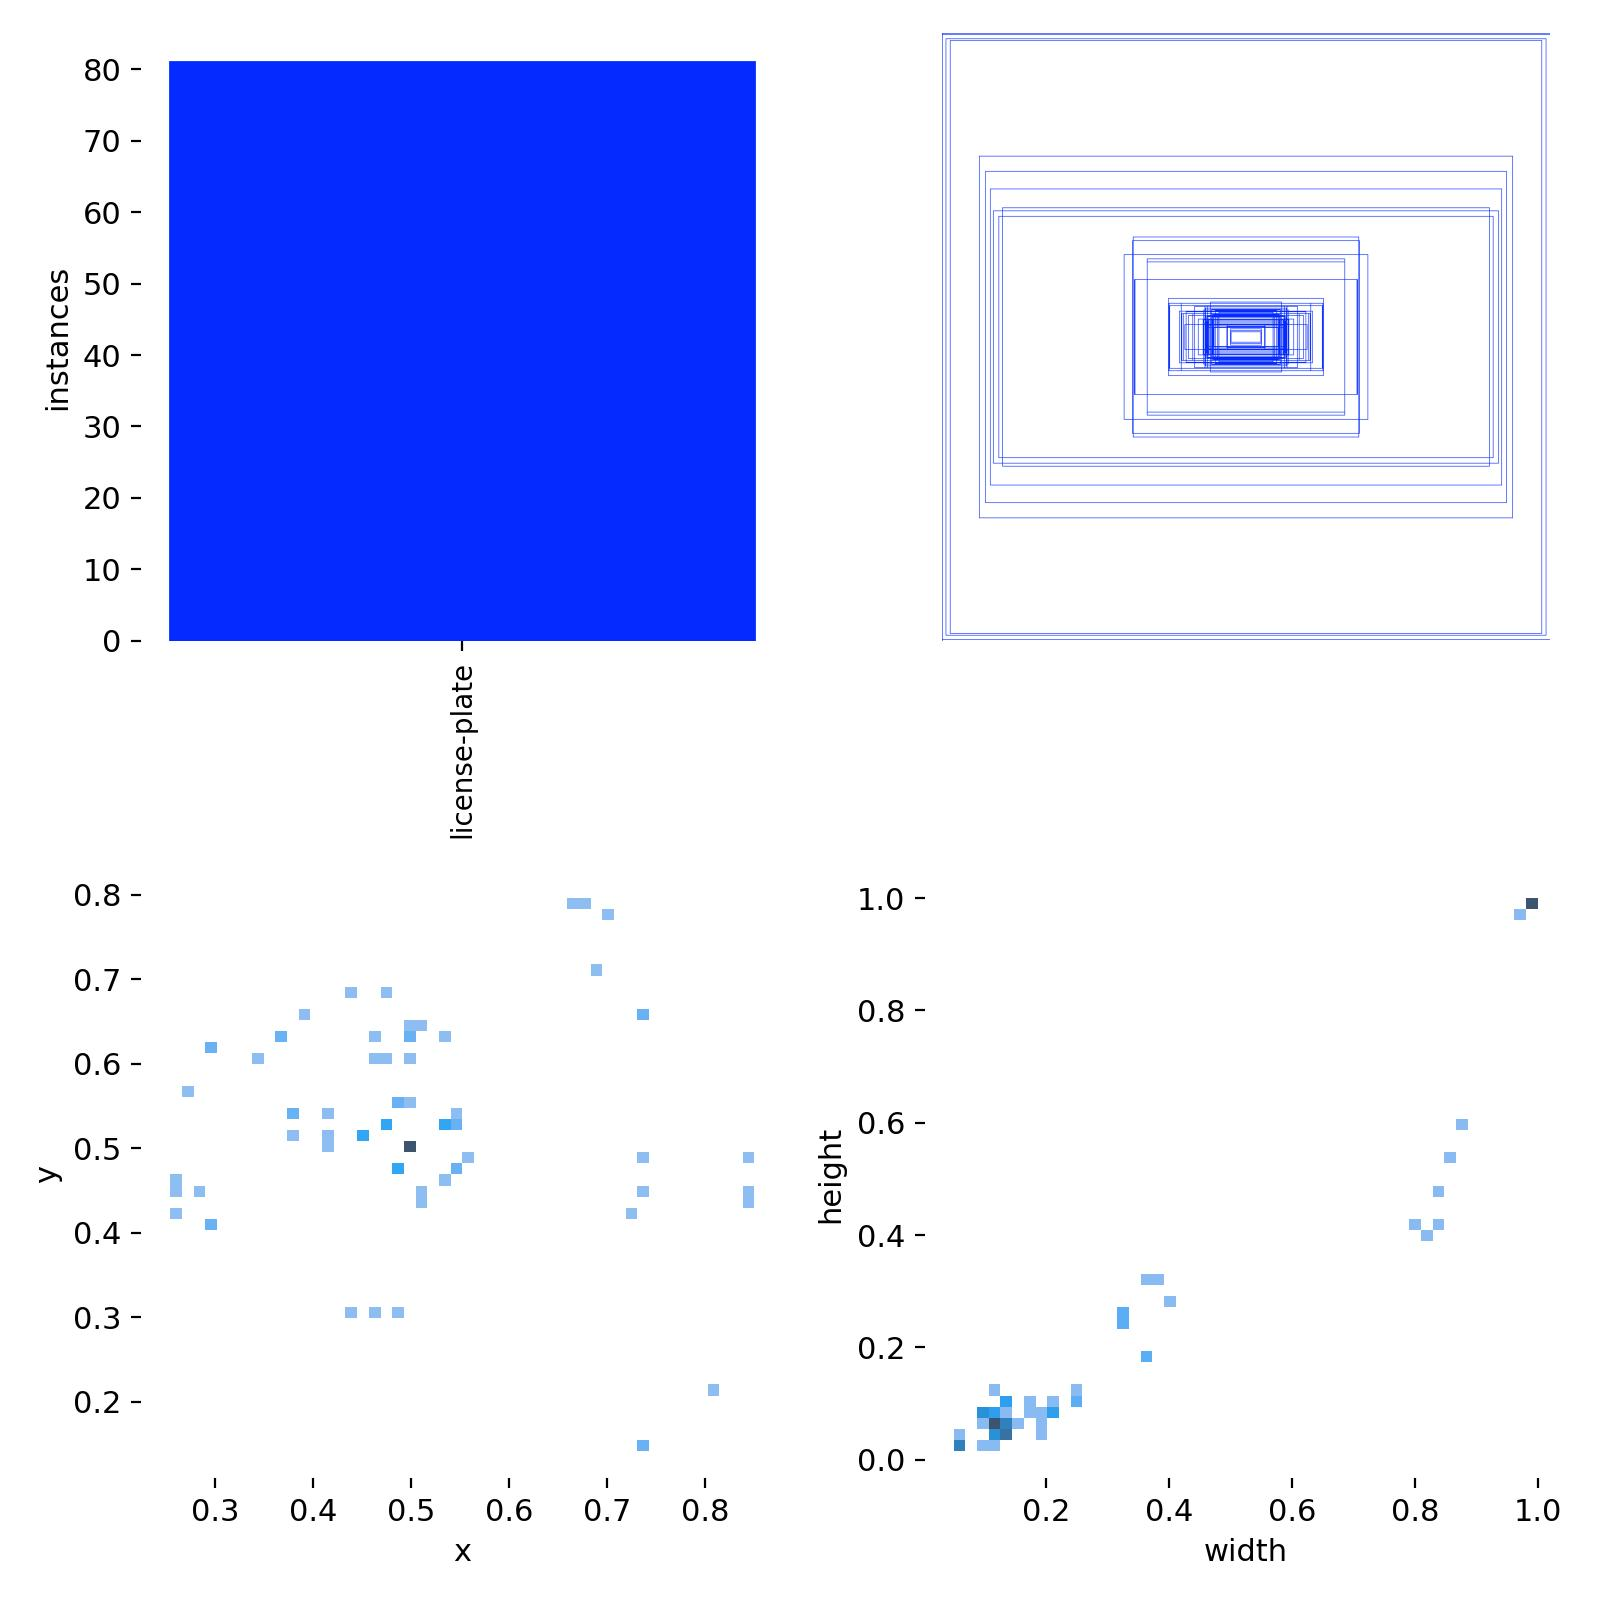

In [ ]:
Image("/content/runs/detect/train2/labels.jpg", width=600)

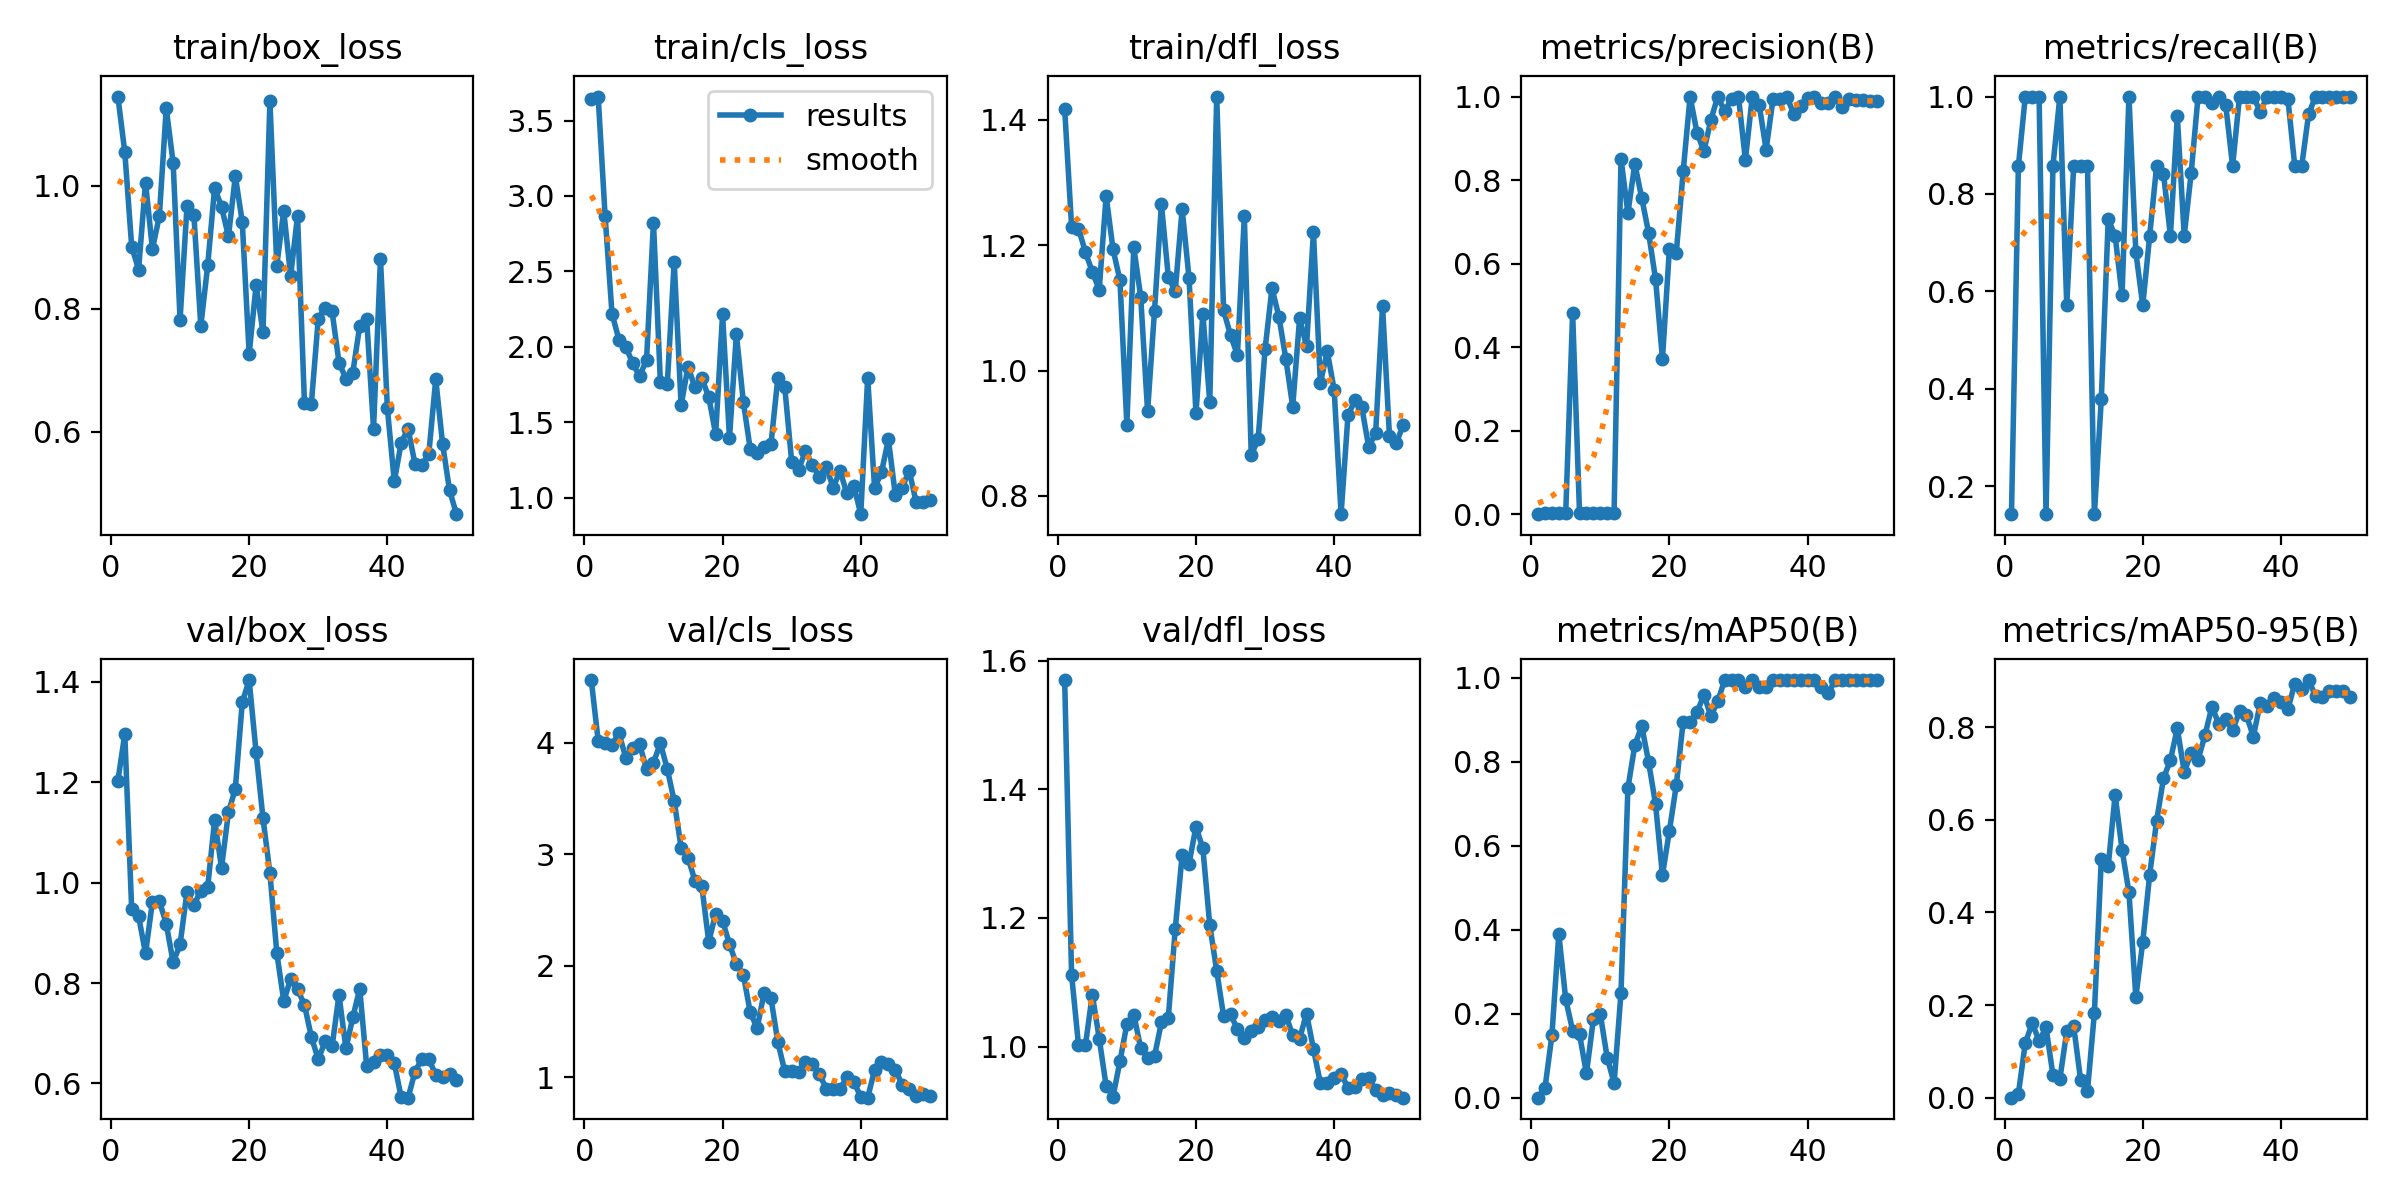

In [ ]:
Image("/content/runs/detect/train2/results.png", width=600)

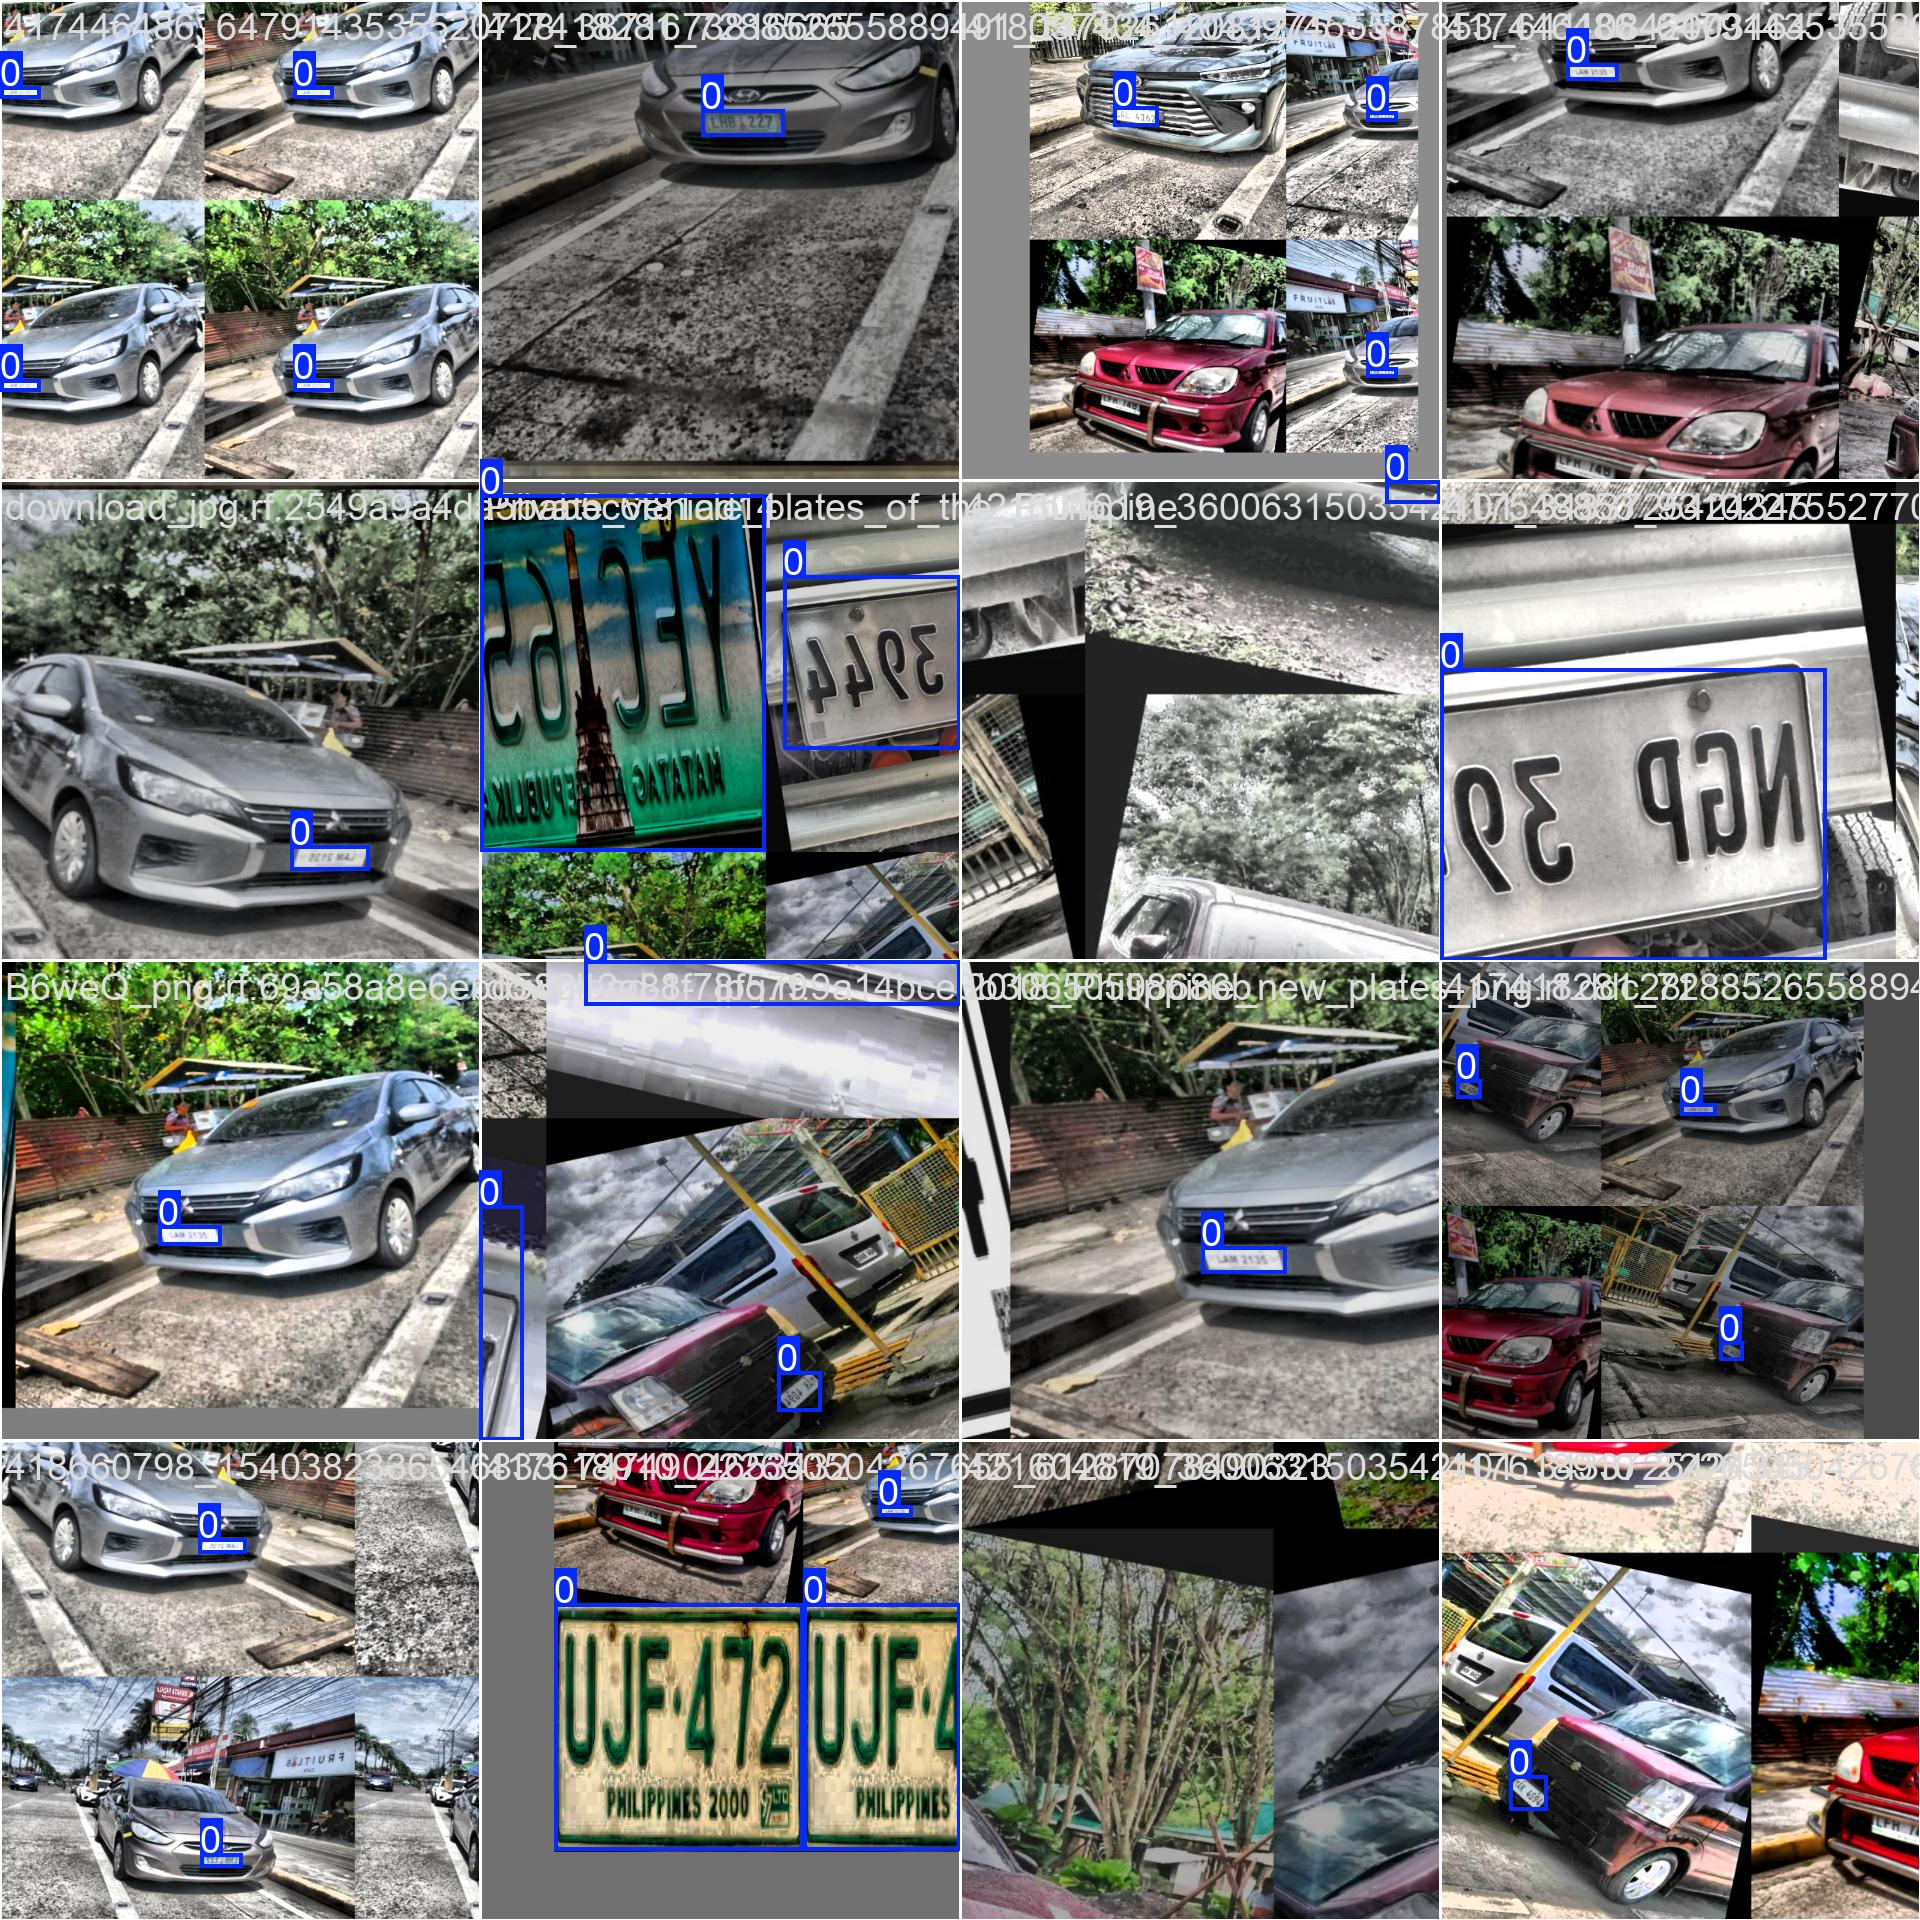

In [ ]:
Image("/content/runs/detect/train2/train_batch0.jpg", width=600)

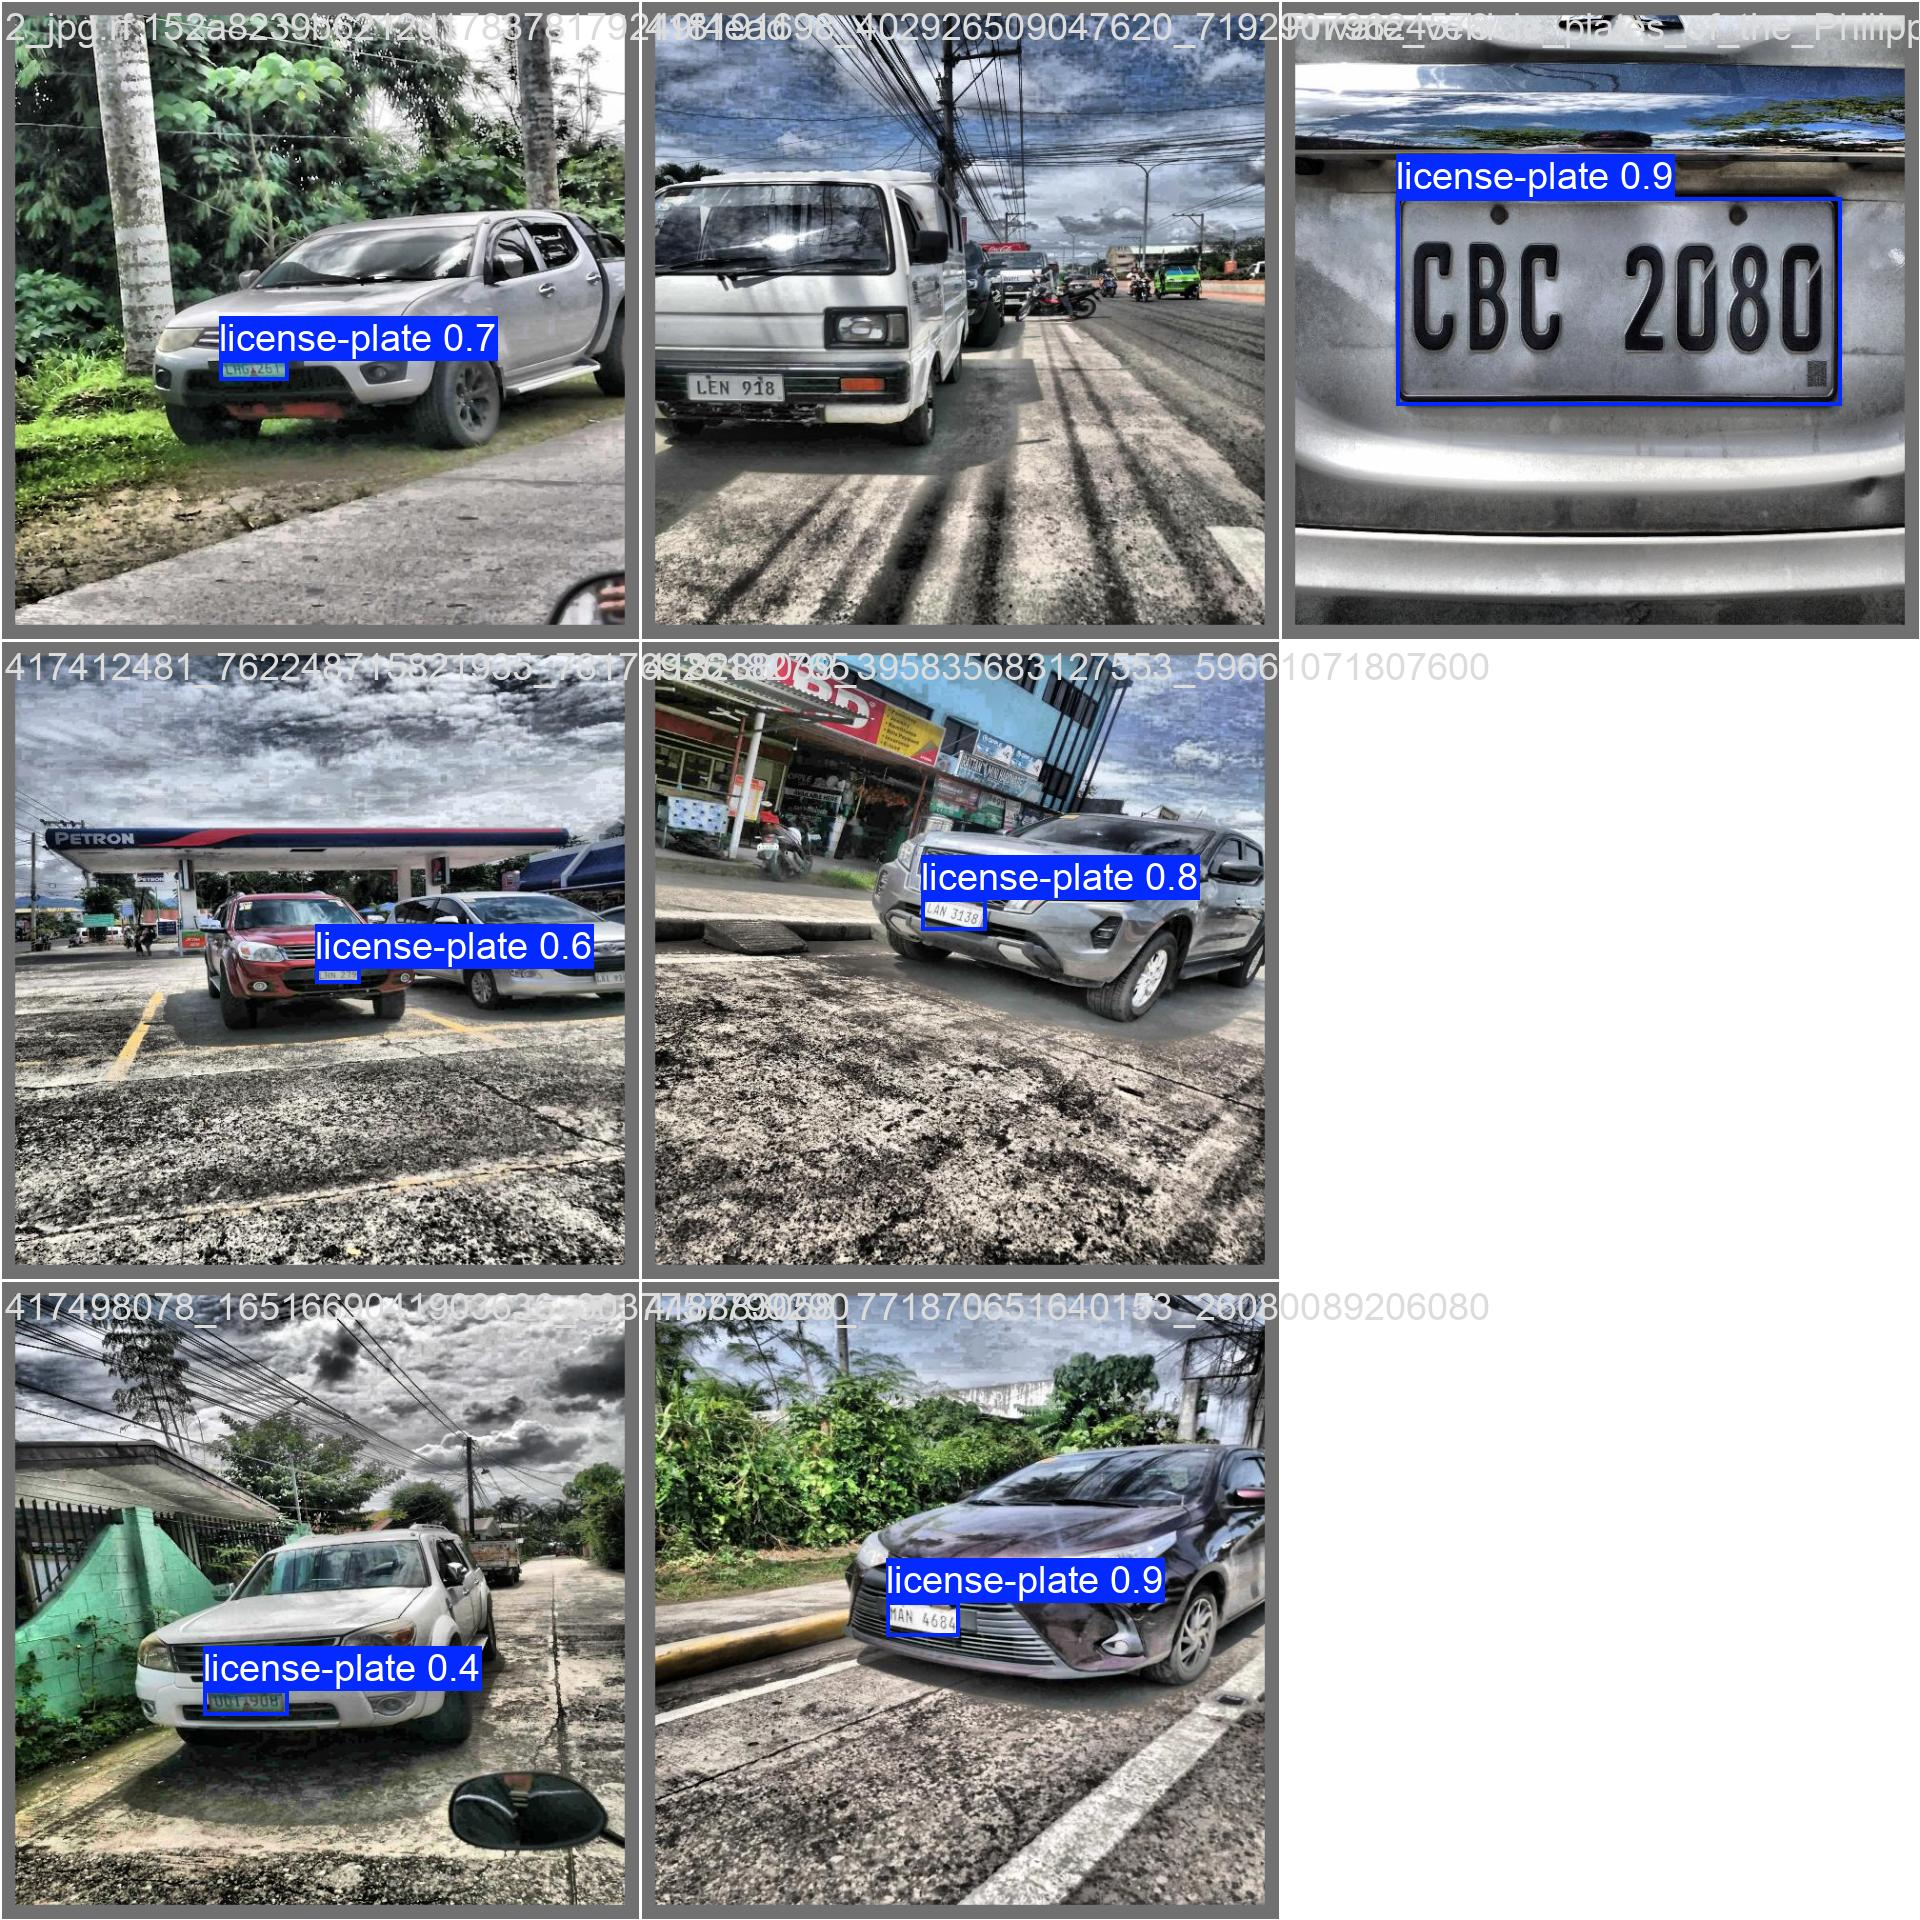

In [ ]:
Image("/content/runs/detect/train2/val_batch0_pred.jpg", width=600)

In [ ]:
!yolo task=detect mode=val model="/content/runs/detect/train2/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/Philippine-license-plates-2/valid/labels.cache... 7 images, 0 backgrounds, 0 corrupt: 100% 7/7 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 6, len(boxes) = 7. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  3.00it/s]
                   all          7          7          1      0.964      0.995      0.892
Speed: 0.3ms preprocess, 10.4ms inference, 0.0ms loss, 19.9ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train2/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

image 1/4 /content/Philippine-license-plates-2/test/images/3_jpg.rf.78acc7ac6ca875da1903c24452db1b6d.jpg: 640x640 1 license-plate, 11.5ms
image 2/4 /content/Philippine-license-plates-2/test/images/417903054_1605303436969623_5508748425222407153_n_jpg.rf.2b05cbd84c497c08ea088c7e72439539.jpg: 640x640 1 license-plate, 8.6ms
image 3/4 /content/Philippine-license-plates-2/test/images/4_jpg.rf.b2969d8a929d34b934a62e4e3607f5a4.jpg: 640x640 1 license-plate, 8.2ms
image 4/4 /content/Philippine-license-plates-2/test/images/Private_vehicle_plates_of_the_Philippines_-2020_Series-_jpg.rf.84758f3383c3ad8622bc5302dbc24ce1.jpg: 640x640 1 license-plate, 7.9ms
Speed: 2.3ms preprocess, 9.1ms inference, 33.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes

In [ ]:
import torch
from ultralytics import YOLO

# Load the trained model
model = YOLO("/content/runs/detect/train2/weights/best.pt") # Load the model using YOLO

# Define test path
test_data = "/content/Philippine-license-plates-2/data.yaml"  # Update with your dataset config file

# Run evaluation
results = model.val(data=test_data)

# Extract metrics
precision = results.results_dict['metrics/precision(B)']  # Precision at IoU threshold 0.5
recall = results.results_dict['metrics/recall(B)']        # Recall at IoU threshold 0.5
map50 = results.results_dict['metrics/mAP50(B)']        # mAP at IoU=0.5
map50_95 = results.results_dict['metrics/mAP50-95(B)']  # mAP averaged over IoU thresholds


# Print results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"mAP@50: {map50:.4f}")
print(f"mAP50-95: {map50_95:.4f}")

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/Philippine-license-plates-2/valid/labels.cache... 7 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7/7 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 6, len(boxes) = 7. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]


                   all          7          7          1      0.964      0.995      0.892
Speed: 0.3ms preprocess, 10.9ms inference, 0.0ms loss, 23.2ms postprocess per image
Results saved to runs/detect/val2
Precision: 1.0000
Recall: 0.9637
mAP@50: 0.9950
mAP50-95: 0.8920
